# 고혈압 예측 - XGBoost Threshold 조정 + SHAP 분석

- 타겟: `고혈압유병` (0: 없음 / 1: 있음)
- 모델: XGBoost (베이스라인과 동일 파라미터)
- 개선 포인트:
  1. **Threshold 조정** — OOF proba 기반 최적 threshold 탐색
  2. **SHAP 분석** — OOF 전체 기준 피처 기여도 해석
- 검증: Stratified 5-Fold CV

In [ ]:

import warnings

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
import xgboost as xgb
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold

warnings.filterwarnings("ignore")
matplotlib.rcParams["font.family"] = "DejaVu Sans"

# ── 경로 설정 ──────────────────────────────────────────────
INPUT_PATH = "/Users/Jiyeon/Desktop/final_project/ML/data/x1_preprocessed.csv"
RANDOM_STATE = 42

## 1. 데이터 로드

In [3]:
df = pd.read_csv(INPUT_PATH)
print(f"로드 완료 | shape: {df.shape}")

로드 완료 | shape: (6033, 32)


## 2. 피처 / 타겟 분리

In [4]:
TARGET = "고혈압유병"
DROP_COLS = ["고혈압유병", "당뇨유병", "이상지질혈증유병", "비만단계"]

data = df.dropna(subset=[TARGET]).copy()
X = data.drop(columns=DROP_COLS)
y = data[TARGET].astype(int)

neg, pos = (y == 0).sum(), (y == 1).sum()
ratio = neg / pos
print(f"샘플 수: {len(y)}  |  정상: {neg}  |  고혈압: {pos}")
print(f"scale_pos_weight: {ratio:.4f}")

샘플 수: 6033  |  정상: 4353  |  고혈압: 1680
scale_pos_weight: 2.5911


## 3. Stratified 5-Fold CV — OOF proba & SHAP 수집

In [5]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
oof_proba = np.zeros(len(y))
shap_values = np.zeros(X.shape)  # OOF SHAP 누적
fold_scores = []

print("=" * 55)
for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    model = xgb.XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        scale_pos_weight=ratio,
        eval_metric="auc",
        early_stopping_rounds=50,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0,
    )
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

    # OOF proba
    proba = model.predict_proba(X_val)[:, 1]
    oof_proba[val_idx] = proba

    # OOF SHAP (TreeExplainer — 빠름)
    explainer = shap.TreeExplainer(model)
    sv = explainer.shap_values(X_val)
    shap_values[val_idx] = sv

    pred = (proba >= 0.5).astype(int)
    cm_f = confusion_matrix(y_val, pred)
    fold_scores.append(
        {
            "fold": fold,
            "auc": roc_auc_score(y_val, proba),
            "f1": f1_score(y_val, pred),
            "recall": recall_score(y_val, pred),
            "precision": precision_score(y_val, pred),
            "fp": int(cm_f[0, 1]),
            "best_iter": model.best_iteration,
        }
    )
    print(
        f"  Fold {fold} | AUC: {fold_scores[-1]['auc']:.4f} | "
        f"Recall: {fold_scores[-1]['recall']:.4f} | "
        f"F1: {fold_scores[-1]['f1']:.4f} | best_iter: {model.best_iteration}"
    )

scores_df = pd.DataFrame(fold_scores)
print("=" * 55)
print(
    f"  평균   | AUC: {scores_df.auc.mean():.4f}±{scores_df.auc.std():.4f} "
    f"| Recall: {scores_df.recall.mean():.4f}±{scores_df.recall.std():.4f} "
    f"| F1: {scores_df.f1.mean():.4f}±{scores_df.f1.std():.4f}"
)

  Fold 1 | AUC: 0.8539 | Recall: 0.8274 | F1: 0.6541 | best_iter: 113
  Fold 2 | AUC: 0.8468 | Recall: 0.7976 | F1: 0.6247 | best_iter: 55
  Fold 3 | AUC: 0.8701 | Recall: 0.8333 | F1: 0.6763 | best_iter: 112
  Fold 4 | AUC: 0.8238 | Recall: 0.7768 | F1: 0.6063 | best_iter: 71
  Fold 5 | AUC: 0.8750 | Recall: 0.8423 | F1: 0.6690 | best_iter: 54
  평균   | AUC: 0.8539±0.0204 | Recall: 0.8155±0.0274 | F1: 0.6461±0.0298


---
# Part 1. Threshold 조정

## 4. Threshold 탐색 (0.30 ~ 0.60)

In [6]:
thresholds = np.arange(0.30, 0.65, 0.05).round(2)
thr_results = []

print(f"{'Threshold':>10} {'Recall':>8} {'Precision':>10} {'F1':>8} {'FP':>6} {'FN':>6}")
print("-" * 55)
for t in thresholds:
    pred_t = (oof_proba >= t).astype(int)
    cm_t = confusion_matrix(y, pred_t)
    rec = recall_score(y, pred_t)
    prec = precision_score(y, pred_t)
    f1 = f1_score(y, pred_t)
    thr_results.append(
        {"threshold": t, "recall": rec, "precision": prec, "f1": f1, "fp": int(cm_t[0, 1]), "fn": int(cm_t[1, 0])}
    )
    marker = "  ◀ baseline" if t == 0.50 else ""
    print(f"{t:>10.2f} {rec:>8.4f} {prec:>10.4f} {f1:>8.4f} {cm_t[0, 1]:>6} {cm_t[1, 0]:>6}{marker}")

thr_df = pd.DataFrame(thr_results)
best_f1 = thr_df.loc[thr_df.f1.idxmax()]
print(
    f"\n★ F1 최고: threshold={best_f1.threshold:.2f} | "
    f"Recall={best_f1.recall:.4f} | F1={best_f1.f1:.4f} | FP={best_f1.fp}"
)

 Threshold   Recall  Precision       F1     FP     FN
-------------------------------------------------------
      0.30   0.9244     0.4623   0.6164   1806    127
      0.35   0.9125     0.4800   0.6291   1661    147
      0.40   0.8923     0.4965   0.6380   1520    181
      0.45   0.8571     0.5103   0.6397   1382    240
      0.50   0.8155     0.5345   0.6458   1193    310  ◀ baseline
      0.55   0.7714     0.5618   0.6501   1011    384
      0.60   0.6940     0.5859   0.6354    824    514

★ F1 최고: threshold=0.55 | Recall=0.7714 | F1=0.6501 | FP=1011.0


## 5. Threshold별 지표 시각화

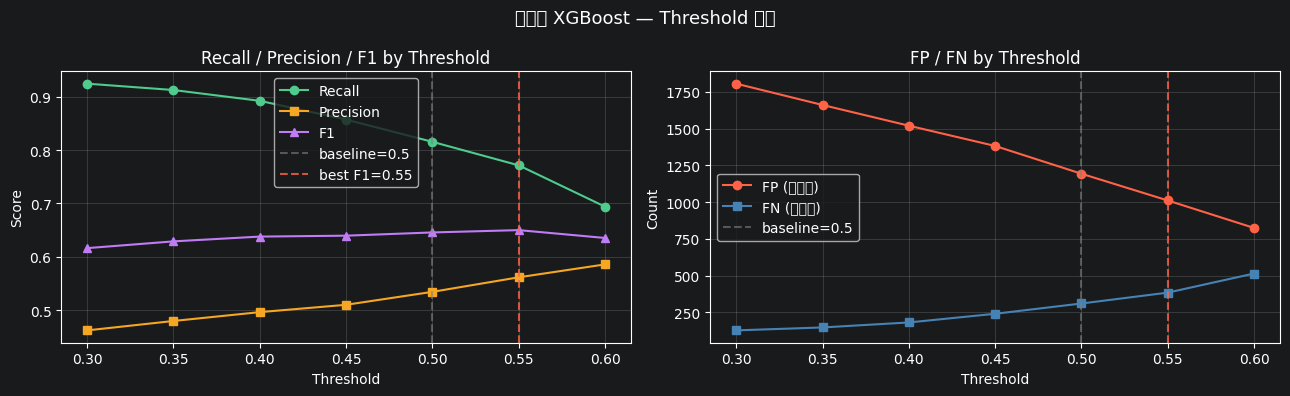

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Recall / Precision / F1
axes[0].plot(thr_df.threshold, thr_df.recall, marker="o", label="Recall", color="#4ecb8d")
axes[0].plot(thr_df.threshold, thr_df.precision, marker="s", label="Precision", color="#f5a623")
axes[0].plot(thr_df.threshold, thr_df.f1, marker="^", label="F1", color="#bf7cf5")
axes[0].axvline(0.5, color="gray", linestyle="--", alpha=0.6, label="baseline=0.5")
axes[0].axvline(best_f1.threshold, color="tomato", linestyle="--", alpha=0.8, label=f"best F1={best_f1.threshold}")
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("Score")
axes[0].set_title("Recall / Precision / F1 by Threshold")
axes[0].legend()
axes[0].grid(alpha=0.3)

# FP / FN
axes[1].plot(thr_df.threshold, thr_df.fp, marker="o", color="tomato", label="FP (과탐지)")
axes[1].plot(thr_df.threshold, thr_df.fn, marker="s", color="steelblue", label="FN (미탐지)")
axes[1].axvline(0.5, color="gray", linestyle="--", alpha=0.6, label="baseline=0.5")
axes[1].axvline(best_f1.threshold, color="tomato", linestyle="--", alpha=0.8)
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("Count")
axes[1].set_title("FP / FN by Threshold")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("고혈압 XGBoost — Threshold 분석", fontsize=13)
plt.tight_layout()
plt.show()

## 6. 최적 Threshold 확정 & 성능 비교

In [8]:
# ── threshold 직접 설정 (탐색 결과 보고 조정 가능) ──
BEST_THRESHOLD = best_f1.threshold  # F1 최고 자동 선택, 필요 시 수동 변경

pred_base = (oof_proba >= 0.50).astype(int)
pred_best = (oof_proba >= BEST_THRESHOLD).astype(int)
cm_base = confusion_matrix(y, pred_base)
cm_best = confusion_matrix(y, pred_best)

print("=" * 52)
print(f"  {'지표':<12}  {'baseline (0.50)':>16}  {f'best ({BEST_THRESHOLD:.2f})':>12}")
print("=" * 52)
metrics = [
    (
        "Recall",
        recall_score,
    ),
    (
        "Precision",
        precision_score,
    ),
    (
        "F1-score",
        f1_score,
    ),
    (
        "AUC-ROC",
        None,
    ),
]
for name, fn in metrics:
    if fn:
        v_base = fn(y, pred_base)
        v_best = fn(y, pred_best)
    else:
        v_base = v_best = roc_auc_score(y, oof_proba)
    delta = v_best - v_base
    arrow = "▲" if delta > 0 else ("▼" if delta < 0 else "─")
    print(f"  {name:<12}  {v_base:>16.4f}  {v_best:>12.4f}  {arrow} {abs(delta):.4f}")
print(f"  {'FP':<12}  {cm_base[0, 1]:>16}  {cm_best[0, 1]:>12}  ▼ {cm_base[0, 1] - cm_best[0, 1]}")
print(f"  {'FN':<12}  {cm_base[1, 0]:>16}  {cm_best[1, 0]:>12}  ▲ {cm_best[1, 0] - cm_base[1, 0]}")
print("=" * 52)

print(f"\n[분류 리포트 — threshold {BEST_THRESHOLD:.2f}]")
print(classification_report(y, pred_best, target_names=["정상(0)", "고혈압(1)"]))

  지표             baseline (0.50)   best (0.55)
  Recall                  0.8155        0.7714  ▼ 0.0440
  Precision               0.5345        0.5618  ▲ 0.0272
  F1-score                0.6458        0.6501  ▲ 0.0043
  AUC-ROC                 0.8531        0.8531  ─ 0.0000
  FP                        1193          1011  ▼ 182
  FN                         310           384  ▲ 74

[분류 리포트 — threshold 0.55]
              precision    recall  f1-score   support

       정상(0)       0.90      0.77      0.83      4353
      고혈압(1)       0.56      0.77      0.65      1680

    accuracy                           0.77      6033
   macro avg       0.73      0.77      0.74      6033
weighted avg       0.80      0.77      0.78      6033



## 7. Confusion Matrix 비교 (baseline vs best threshold)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, cm, title in zip(
    axes, [cm_base, cm_best], ["Baseline (threshold=0.50)", f"Best (threshold={BEST_THRESHOLD:.2f})"], strict=True,
):
    ConfusionMatrixDisplay(cm, display_labels=["정상(0)", "고혈압(1)"]).plot(cmap="Blues", ax=ax, colorbar=False, strict=True,)
    ax.set_title(title)
plt.suptitle("고혈압 XGBoost — Confusion Matrix 비교", fontsize=13)
plt.tight_layout()
plt.show()

## 8. Precision-Recall 커브

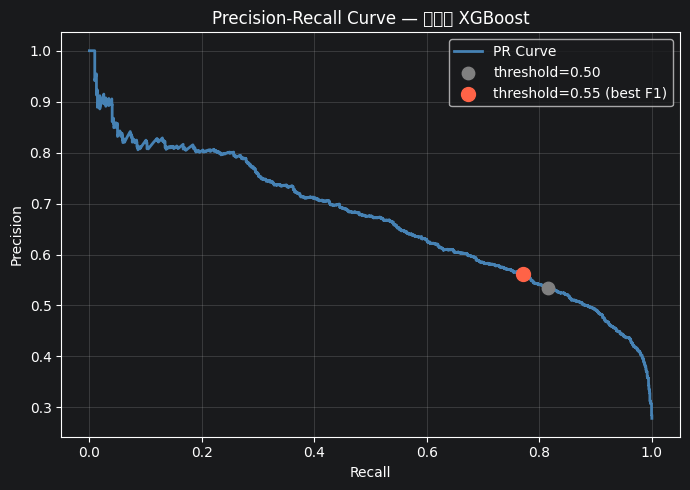

In [10]:
prec_curve, rec_curve, thr_curve = precision_recall_curve(y, oof_proba)

plt.figure(figsize=(7, 5))
plt.plot(rec_curve, prec_curve, color="steelblue", lw=2, label="PR Curve")
# baseline 0.5 마킹
idx_base = np.argmin(np.abs(thr_curve - 0.50))
plt.scatter(rec_curve[idx_base], prec_curve[idx_base], s=80, color="gray", zorder=5, label="threshold=0.50")
# best threshold 마킹
idx_best = np.argmin(np.abs(thr_curve - BEST_THRESHOLD))
plt.scatter(
    rec_curve[idx_best],
    prec_curve[idx_best],
    s=100,
    color="tomato",
    zorder=5,
    label=f"threshold={BEST_THRESHOLD:.2f} (best F1)",
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — 고혈압 XGBoost")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
# Part 2. SHAP 분석

## 9. SHAP Summary Plot (OOF 전체)

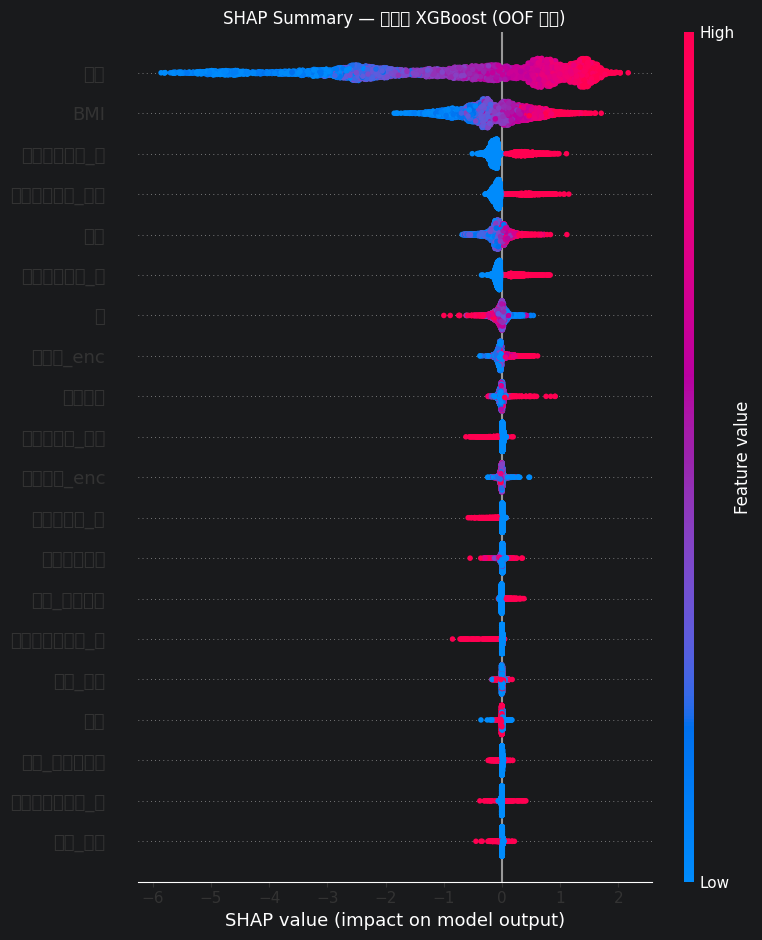

In [11]:
# OOF 전체 기준 SHAP — beeswarm plot
shap.summary_plot(shap_values, X, plot_type="dot", max_display=20, show=False)
plt.title("SHAP Summary — 고혈압 XGBoost (OOF 전체)", fontsize=12)
plt.tight_layout()
plt.show()

## 10. SHAP Feature Importance (mean |SHAP|)

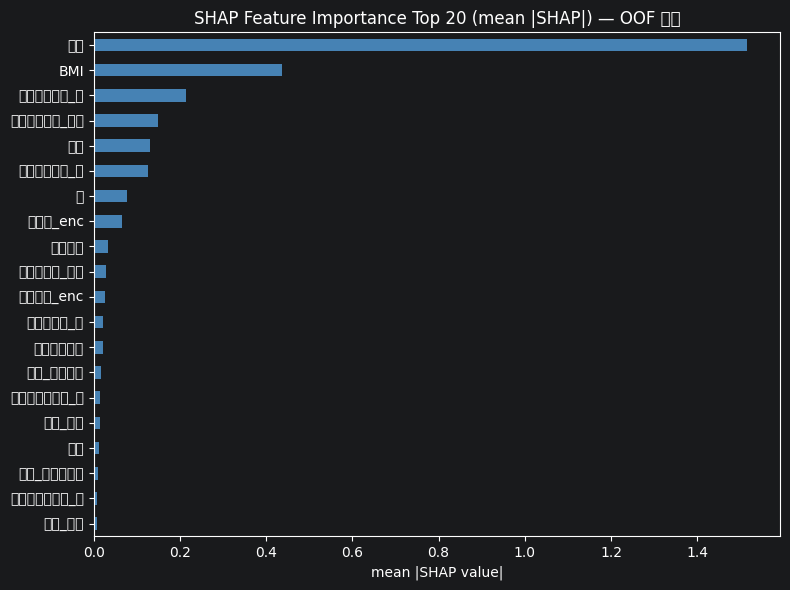

[SHAP Feature Importance Top 20]
   1. 나이: 1.5161
   2. BMI: 0.4363
   3. 고혈압가족력_모: 0.2132
   4. 고혈압가족력_형제: 0.1500
   5. 체중: 0.1313
   6. 고혈압가족력_부: 0.1251
   7. 키: 0.0761
   8. 음주량_enc: 0.0650
   9. 걷기일수: 0.0335
  10. 당뇨가족력_형제: 0.0285
  11. 음주빈도_enc: 0.0252
  12. 당뇨가족력_부: 0.0209
  13. 근력운동일수: 0.0204
  14. 직업_주부학생: 0.0159
  15. 고지혈증가족력_모: 0.0148
  16. 직업_무직: 0.0135
  17. 성별: 0.0124
  18. 직업_서비스판매: 0.0110
  19. 고지혈증가족력_부: 0.0086
  20. 직업_사무: 0.0085


In [12]:
mean_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=X.columns).sort_values(ascending=False)

# 시각화
plt.figure(figsize=(8, 6))
mean_shap.head(20)[::-1].plot(kind="barh", color="steelblue")
plt.title("SHAP Feature Importance Top 20 (mean |SHAP|) — OOF 전체")
plt.xlabel("mean |SHAP value|")
plt.tight_layout()
plt.show()

print("[SHAP Feature Importance Top 20]")
for i, (feat, val) in enumerate(mean_shap.head(20).items(), 1):
    print(f"  {i:2d}. {feat}: {val:.4f}")

## 11. SHAP Bar Plot (전체 피처 기여도 요약)

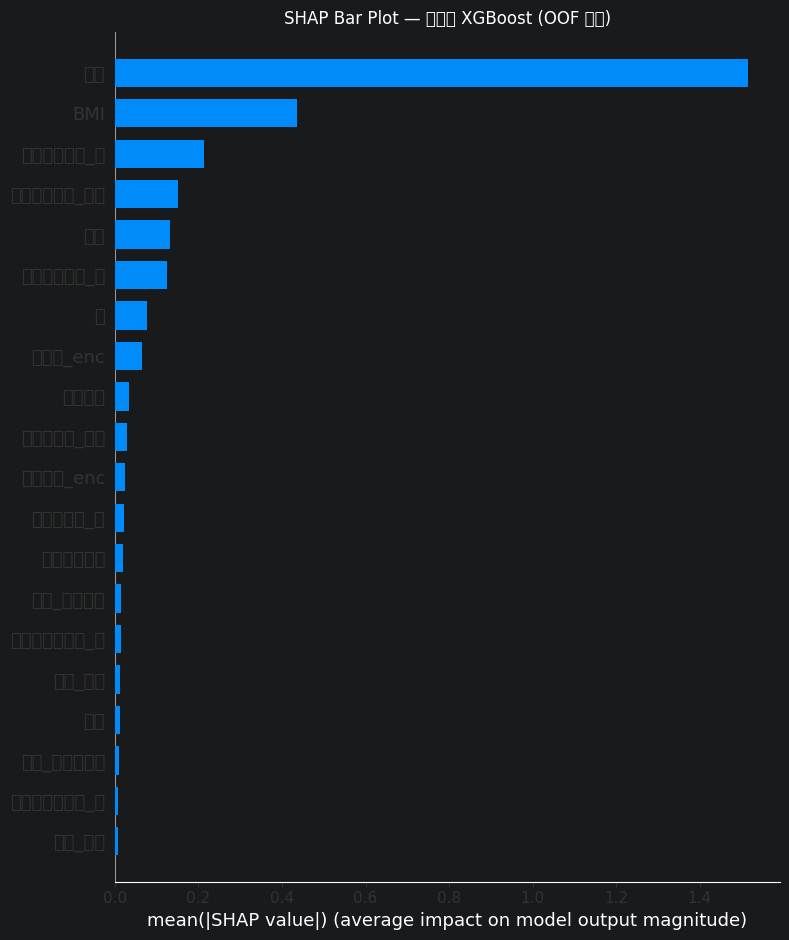

In [13]:
shap.summary_plot(shap_values, X, plot_type="bar", max_display=20, show=False)
plt.title("SHAP Bar Plot — 고혈압 XGBoost (OOF 전체)", fontsize=12)
plt.tight_layout()
plt.show()

## 12. SHAP Dependence Plot — 상위 피처 (나이, BMI)

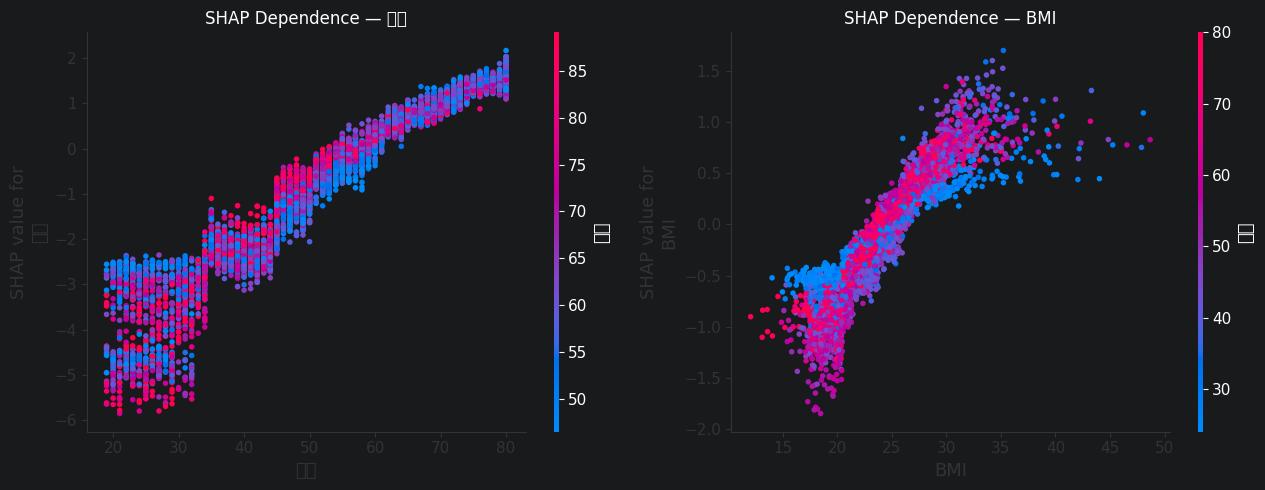

In [14]:
top2 = mean_shap.head(2).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, feat in zip(axes, top2):
    shap.dependence_plot(feat, shap_values, X, ax=ax, show=False)
    ax.set_title(f"SHAP Dependence — {feat}")
plt.tight_layout()
plt.show()

## 13. SHAP Waterfall — 고위험 예측 샘플 개별 해석

샘플 인덱스: 4944
예측 확률: 0.9717
실제 레이블: 1
threshold 0.55 기준 예측: 1


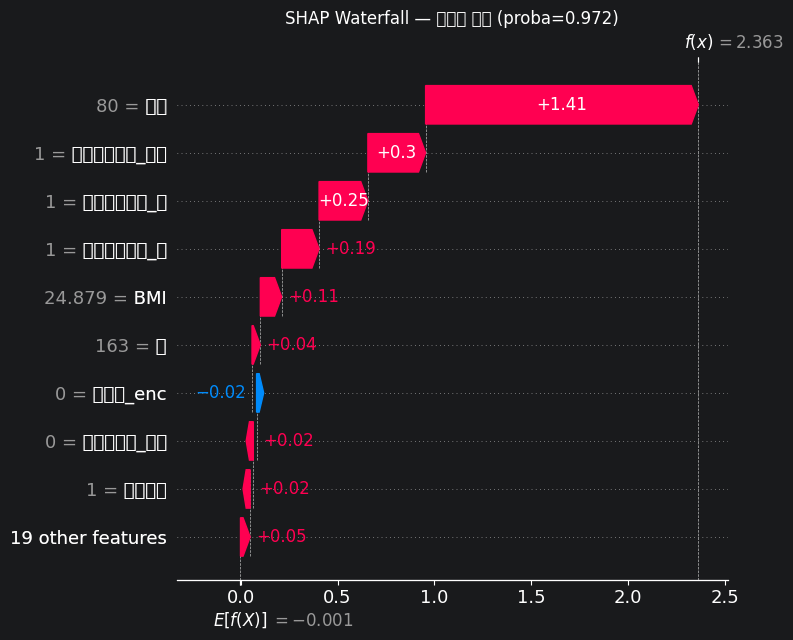

In [15]:
# 고위험(예측 확률 상위 5) 샘플 중 첫 번째
high_risk_idx = np.argsort(oof_proba)[::-1][:5]
sample_idx = high_risk_idx[0]

explainer_last = shap.TreeExplainer(model)
shap_exp = explainer_last(X.iloc[[sample_idx]])

print(f"샘플 인덱스: {sample_idx}")
print(f"예측 확률: {oof_proba[sample_idx]:.4f}")
print(f"실제 레이블: {y.iloc[sample_idx]}")
print(f"threshold {BEST_THRESHOLD:.2f} 기준 예측: {int(oof_proba[sample_idx] >= BEST_THRESHOLD)}")

shap.waterfall_plot(shap_exp[0], show=False)
plt.title(f"SHAP Waterfall — 고위험 샘플 (proba={oof_proba[sample_idx]:.3f})")
plt.tight_layout()
plt.show()

## 14. DB 로그 저장

In [16]:
import sys

sys.path.insert(0, "/Users/Jiyeon/Desktop/final_project/ML")
from model_logger import ModelLogger

logger = ModelLogger("/Users/Jiyeon/Desktop/final_project/ML/model_result.db")

pred_final = (oof_proba >= BEST_THRESHOLD).astype(int)
cm_final = confusion_matrix(y, pred_final)

run_id = logger.log_run(
    target_var="고혈압",
    model_name="XGBoost",
    stage=f"threshold_{BEST_THRESHOLD:.2f}",
    hyperparams={
        "learning_rate": 0.05,
        "max_depth": 6,
        "n_estimators": 500,
        "class_weight": {0: 1.0, 1: round(ratio, 4)},
        "eval_metric": "auc",
        "early_stopping_rounds": 50,
    },
    data_info={
        "feature_count": X.shape[1],
        "train_test_split": "5-Fold CV",
        "scaling_method": "None",
    },
    oof_metrics={
        "accuracy": float((pred_final == y).mean()),
        "recall": recall_score(y, pred_final),
        "precision": precision_score(y, pred_final),
        "f1_score": f1_score(y, pred_final),
        "auc_roc": roc_auc_score(y, oof_proba),
        "cm": cm_final.tolist(),
    },
    fold_scores=scores_df.to_dict("records"),
    threshold_results=thr_df.to_dict("records"),
    top_features=mean_shap.head(15).to_dict(),  # SHAP 기반 importance
    note=f"threshold {BEST_THRESHOLD:.2f} 조정 + SHAP 분석. SHAP mean|shap| 기준 top_features.",
)

print(f"저장 완료 → run_id: {run_id}")
print()
print("[전체 실험 목록]")
print(logger.compare_runs().to_string(index=False))

[ModelLogger] 저장 완료 | run_id=1 | 고혈압 XGBoost (threshold_0.55)
저장 완료 → run_id: 1

[전체 실험 목록]
 run_id          created_at target_var model_name          stage  auc_roc   recall  precision  f1_score  accuracy
      1 2026-05-15 15:30:15        고혈압    XGBoost threshold_0.55 0.853083 0.771429   0.561769  0.650113  0.768772
